In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os 

# SETUP FOLDER PENYIMPANAN GAMBAR
# Kita buat folder otomatis biar tidak error
save_dir = '../output/figures/cleveland/'
os.makedirs(save_dir, exist_ok=True)
print(f"📂 Folder penyimpanan gambar siap di: {save_dir}")

📂 Folder penyimpanan gambar siap di: ../output/figures/cleveland/


## Preview Dataset

In [6]:
# ==========================================
# 2. MEMUAT DATASET (DATA LOADING)
# ==========================================
dataset = pd.read_csv('../data/cleveland.csv') # Membaca file CSV mentah dari folder data)
dataset.head() # Menampilkan 5 baris pertama untuk inspeksi awal struktur data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,label
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,A
1,37,1,3,130,250,0,0,187,0,3.5,3,0,3,A
2,41,0,2,130,204,0,2,172,0,1.4,1,0,3,A
3,56,1,2,120,236,0,0,178,0,0.8,1,0,3,A
4,57,0,4,120,354,0,0,163,1,0.6,1,0,3,A


## Check tipe Data

In [ ]:
# ==========================================
# 3. PEMERIKSAAN TIPE DATA (DATA TYPES)
# ==========================================
dataset.info() # Menampilkan ringkasan tipe data pada attribute DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  label     303 non-null    object 
dtypes: float64(1), int64(12), object(1)
memory usage: 33.3+ KB


## Check Konsistensi

In [ ]:
# ==========================================
# 4. CEK KONSISTENSI DATA (CATEGORICAL CHECK)
# ==========================================
# Memilih hanya kolom dengan tipe data 'object' (kategorikal/string)
kolom_object = dataset.select_dtypes(include=['object']).columns 

# Loop untuk mengecek variasi nilai unik
# Tujuan: Mendeteksi jika ada label yang tidak konsisten (typo/format salah)
for col in kolom_object:
    print(f"\nNilai unik di kolom '{col}':")
    print(dataset[col].unique())
    print(f"Jumlah nilai unik: {len(dataset[col].unique())}")


Nilai unik di kolom 'label':
['A' 'B' 'C' 'D' 'E']
Jumlah nilai unik: 5


## Check Duplikasi

In [ ]:
# ==========================================
# 5. CEK DUPLIKASI DATA (DUPLICATE CHECK)
# ==========================================
check_duplicate = dataset.duplicated().sum() # Menghitung jumlah baris yang isinya sama persis (duplikat)
print(f"Jumlah dataset duplikat {check_duplicate}") # output

Jumlah dataset duplikat 0


## Check Data Hilang

In [ ]:
# ==========================================
# 6. CEK MISSING VALUES (DATA HILANG)
# ==========================================
# Menghitung jumlah nilai Null/NaN di setiap kolom
check_null = dataset.isna().sum() 

# Menampilkan laporan jika ada kolom yang datanya kosong
if check_null.sum() > 0:
    print(f"\nKolom dengan Missing Values dataset")
    print(f"{check_null[check_null > 0]}")
else:
    print(f"Tidak ditemuka data kosong atau Null dataset")

Tidak ditemuka data kosong atau Null dataset


## Check Korelasi Kesalahan Input

In [ ]:
# ==========================================
# 7. VALIDASI LOGIKA (DATA INTEGRITY CHECK)
# ==========================================
error_report = []

# Daftar kolom yang seharusnya berisi angka (numerik)
numeric_candidates = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# [A] Validasi Tipe Data Numerik
for col in numeric_candidates:
    # errors='coerce': Paksa ubah ke angka, jika gagal (teks) akan jadi NaN
    test_convert = pd.to_numeric(dataset[col], errors='coerce')
    
    # Cek apakah ada data yang berubah jadi NaN 
    new_nans = test_convert.isna().sum() - dataset[col].isna().sum()
    
    if new_nans > 0:
        error_report.append(f"[TIPE DATA] Kolom '{col}': Ditemukan {new_nans} baris non-angka.")
    else:
        print(f"✓ Kolom '{col}' format data aman (numerik).")

# [B] Validasi Logika Medis
# Mengecek apakah nilai masuk akal
logic_rules = [
    ('age', dataset['age'] <= 0, "Umur bernilai 0 atau negatif"),
    ('age', dataset['age'] > 120, "Umur tidak wajar"),
    ('trestbps', dataset['trestbps'] <= 0, "Tekanan darah 0 atau negatif"),
    ('chol', dataset['chol'] <= 0, "Kolesterol 0 atau negatif"),
    ('thalach', dataset['thalach'] <= 0, "Detak jantung 0 atau negatif"),
    ('sex', ~dataset['sex'].isin([0, 1]), "Nilai Sex bukan 0 atau 1")
]

for col_name, condition, message in logic_rules:
    if condition.sum() > 0:
        error_report.append(f"[LOGIKA] Kolom '{col_name}': {message}")

✓ Kolom 'age' format data aman (numerik).
✓ Kolom 'trestbps' format data aman (numerik).
✓ Kolom 'chol' format data aman (numerik).
✓ Kolom 'thalach' format data aman (numerik).
✓ Kolom 'oldpeak' format data aman (numerik).


## Check Outlier

In [ ]:
# ==========================================
# 8. DETEKSI OUTLIER (METODE IQR)
# ==========================================
# Mengambil kolom numerik untuk analisis statistik
numerical_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = []
outlier_details = {} 

for col in numerical_cols:
    # Menghitung Kuartil 1 (25%) dan Kuartil 3 (75%)
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1 # Interquartile Range (Jangkauan Antar Kuartil)
    
    # Menentukan batas wajar (Threshold)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_details[col] = {'lower': lower_bound, 'upper': upper_bound}
    
    # Menghitung jumlah data di luar batas wajar
    total_outliers = ((dataset[col] < lower_bound) | (dataset[col] > upper_bound)).sum()
    
    if total_outliers > 0:
        outlier_summary.append({
            'Kolom': col,
            'Outliers': total_outliers,
            'Batas Bawah': round(lower_bound, 2),
            'Batas Atas': round(upper_bound, 2)
        })

# Menampilkan tabel ringkasan outlier
if len(outlier_summary) > 0:
    print(f"\nRincian Outlier Ditemukan (Total {len(outlier_summary)} kolom bermasalah):")
    display(pd.DataFrame(outlier_summary))
else:
    print("\nTidak ditemukan outlier yang signifikan.")

--- Memulai Perhitungan IQR ---

Rincian Outlier Ditemukan (Total 7 kolom bermasalah):


,Kolom,Outliers,Batas Bawah,Batas Atas
0,cp,23,1.50,5.50
1,trestbps,9,90.00,170.00
2,chol,5,115.00,371.00
3,fbs,45,0.00,0.00
4,thalach,1,84.75,214.75
5,oldpeak,5,-2.40,4.00
6,ca,20,-1.50,2.50


In [ ]:
# ==========================================
# 8a. VISUALISASI OUTLIER (SCATTER PLOT)
# ==========================================
print("\n--- Menampilkan Visualisasi Sebaran Data (Outlier) ---")

# Loop untuk menampilkan plot satu per satu untuk setiap kolom numerik
for col in numerical_cols:
    # --- 1. Ambil Batas IQR dari System Sebelumnya ---
    # Mengambil nilai batas yang sudah dihitung di tahap 8a
    lower_bound = outlier_details[col]['lower']
    upper_bound = outlier_details[col]['upper']
    
    # --- 2. Setup Canvas ---
    # Mengatur ukuran gambar agar jelas terbaca
    plt.figure(figsize=(12, 6))
    
    # --- 3. Plotting Data ---
    # List Comprehension: Memberi warna 'red' jika data outlier, 'royalblue' jika normal
    colors = ['red' if (x < lower_bound or x > upper_bound) else 'royalblue' for x in dataset[col]]
    
    # Membuat scatter plot
    # s=100 (ukuran titik), alpha=0.7 (transparansi)
    plt.scatter(dataset.index, dataset[col], c=colors, s=100, alpha=0.7)
    
    # --- 4. Gambar Garis Batas ---
    # Membuat garis horizontal putus-putus merah sebagai batas atas & bawah
    plt.axhline(y=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper Bound ({upper_bound:.2f})')
    plt.axhline(y=lower_bound, color='red', linestyle='--', linewidth=2, label=f'Lower Bound ({lower_bound:.2f})')
    
    # Arsir area normal dengan warna hijau transparan
    plt.axhspan(lower_bound, upper_bound, color='green', alpha=0.05, label='Normal Range')

    # --- 5. Kosmetik Grafik ---
    # Menambahkan judul dan label sumbu
    plt.title(f'Deteksi Outlier: {col}', fontsize=16, fontweight='bold')
    plt.ylabel(f'Nilai {col}', fontsize=12)
    plt.xlabel('Index Data', fontsize=12)
    plt.legend(loc='upper right') # Menampilkan legenda
    plt.grid(True, linestyle='--', alpha=0.5) # Menampilkan grid tipis
    
    # Tampilkan grafik ke layar
    plt.show()


--- Menampilkan Visualisasi Sebaran Data (Outlier) ---


NameError: name 'numerical_cols' is not defined


--- Menampilkan Visualisasi Sebaran Data (Outlier) ---
📸 Gambar tersimpan: analisis_outlier_scatter_grid.png


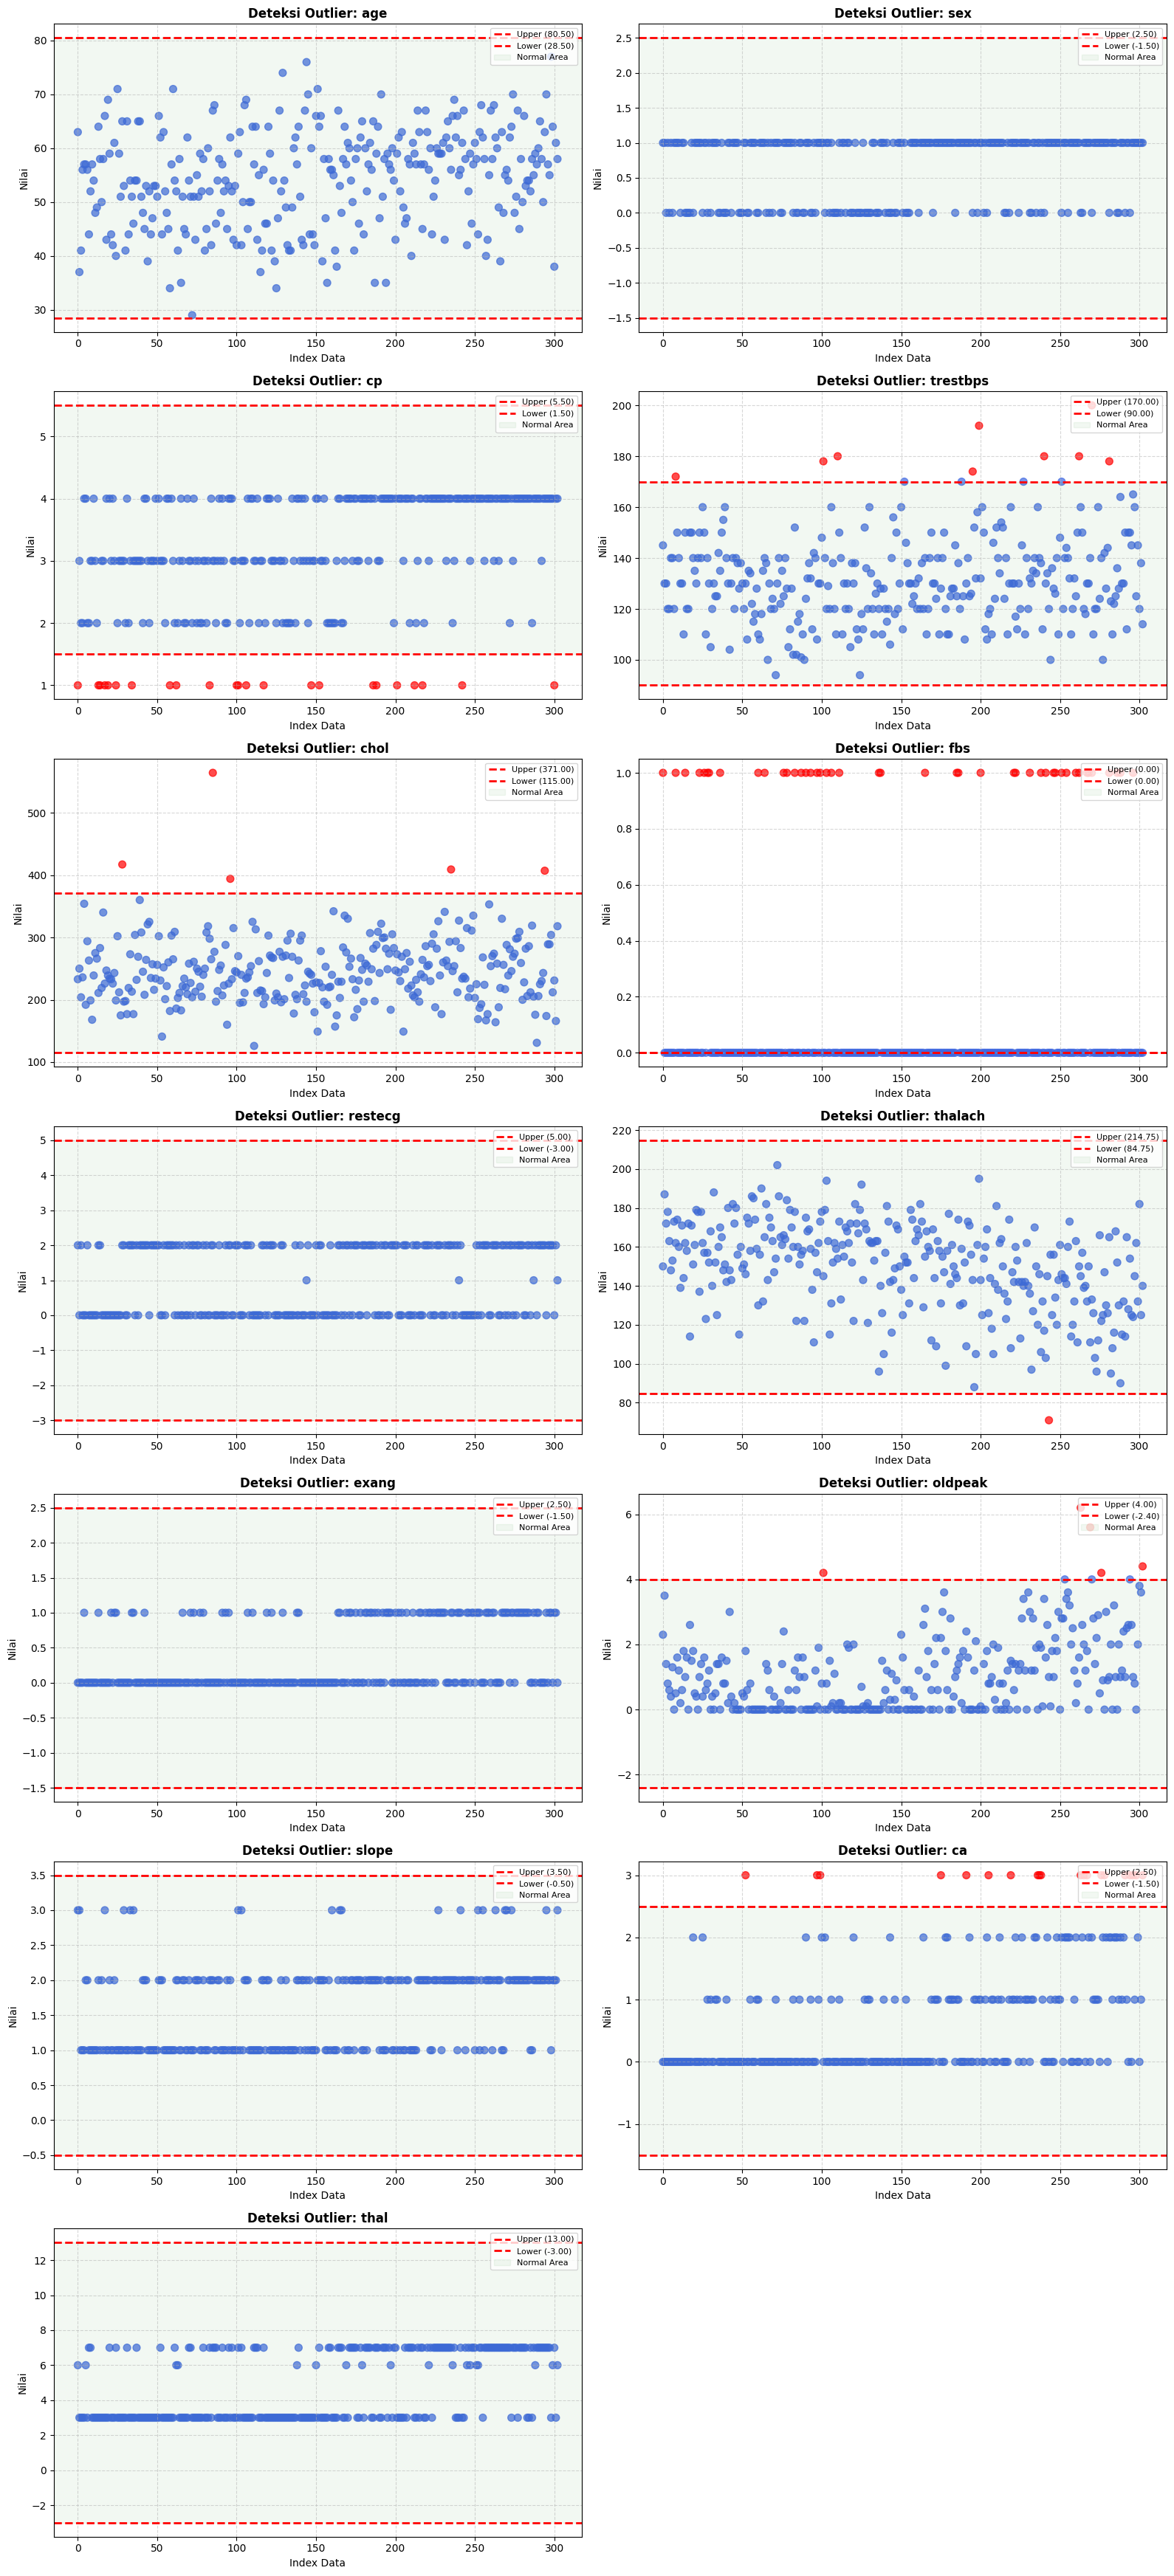

In [ ]:
# ==========================================
# 8b. VISUALISASI OUTLIER 
# ==========================================
# Bagian ini menampilkan scatter plot untuk semua fitur numerik dalam satu gambar besar.
# Tujuannya memudahkan melihat distribusi data pencilan (outlier) secara menyeluruh.

# 1. Tentukan Ukuran Grid (Layout)
# Kita menggunakan layout 2 kolom agar grafik cukup lebar untuk dibaca
n_cols = 2
# Hitung jumlah baris yang dibutuhkan (Total Kolom dibagi 2, dibulatkan ke atas)
n_rows = math.ceil(len(numerical_cols) / n_cols)

# Atur ukuran canvas (Figure)
# figsize=(Lebar, Tinggi). Tinggi diset dinamis (5 * n_rows) agar gambar tidak gepeng.
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))

# Ratakan array axes agar mudah di-loop (dari matriks 2D menjadi array 1D)
axes = axes.flatten()

# 2. Loop Plotting ke dalam Subplot
for i, col in enumerate(numerical_cols):
    ax = axes[i] # Pilih kotak (axis) yang aktif sesuai urutan loop
    
    # --- Ambil Batas IQR dari Perhitungan Sebelumnya ---
    lower_bound = outlier_details[col]['lower']
    upper_bound = outlier_details[col]['upper']
    
    # --- Tentukan Warna Titik ---
    # List Comprehension: Merah jika outlier, Biru royal jika data normal
    colors = ['red' if (x < lower_bound or x > upper_bound) else 'royalblue' for x in dataset[col]]
    
    # --- Gambar Scatter Plot ---
    # s=50: Ukuran titik
    # alpha=0.7: Transparansi titik
    ax.scatter(dataset.index, dataset[col], c=colors, s=50, alpha=0.7)
    
    # --- Gambar Garis Batas & Arsiran ---
    # Garis putus-putus merah untuk batas atas & bawah
    ax.axhline(y=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper ({upper_bound:.2f})')
    ax.axhline(y=lower_bound, color='red', linestyle='--', linewidth=2, label=f'Lower ({lower_bound:.2f})')
    # Arsir area hijau tipis untuk menandakan "Zona Aman" (Normal Range)
    ax.axhspan(lower_bound, upper_bound, color='green', alpha=0.05, label='Normal Area')
    
    # --- Kosmetik Grafik per Kotak ---
    ax.set_title(f'Deteksi Outlier: {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Nilai')
    ax.set_xlabel('Index Data')
    ax.legend(loc='upper right', fontsize=8) # Legenda kecil di pojok kanan atas
    ax.grid(True, linestyle='--', alpha=0.5) # Grid tipis untuk bantu baca nilai

# 3. Hapus Kotak Kosong (Jika jumlah plot ganjil)
# Misal ada 5 fitur, grid 2x3 = 6 kotak. Kotak ke-6 harus dihapus biar rapi.
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 4. Simpan & Tampilkan Canvas
# tight_layout(): Otomatis mengatur jarak antar grafik biar judul/label tidak tabrakan
plt.tight_layout() 

# --- SIMPAN GAMBAR KE FOLDER ---
# Simpan gambar dengan resolusi tinggi (300 dpi) agar bagus di PowerPoint
nama_file_outlier = 'analisis_outlier_scatter_grid.png'
plt.savefig(os.path.join(save_dir, nama_file_outlier), dpi=300, bbox_inches='tight')
print(f"📸 Gambar tersimpan: {nama_file_outlier}")

plt.show()

## Check Distribusi Data


--- Analisis Kemiringan Distribusi Data (Skewness) ---
📸 Gambar tersimpan: distribusi_skewness.png


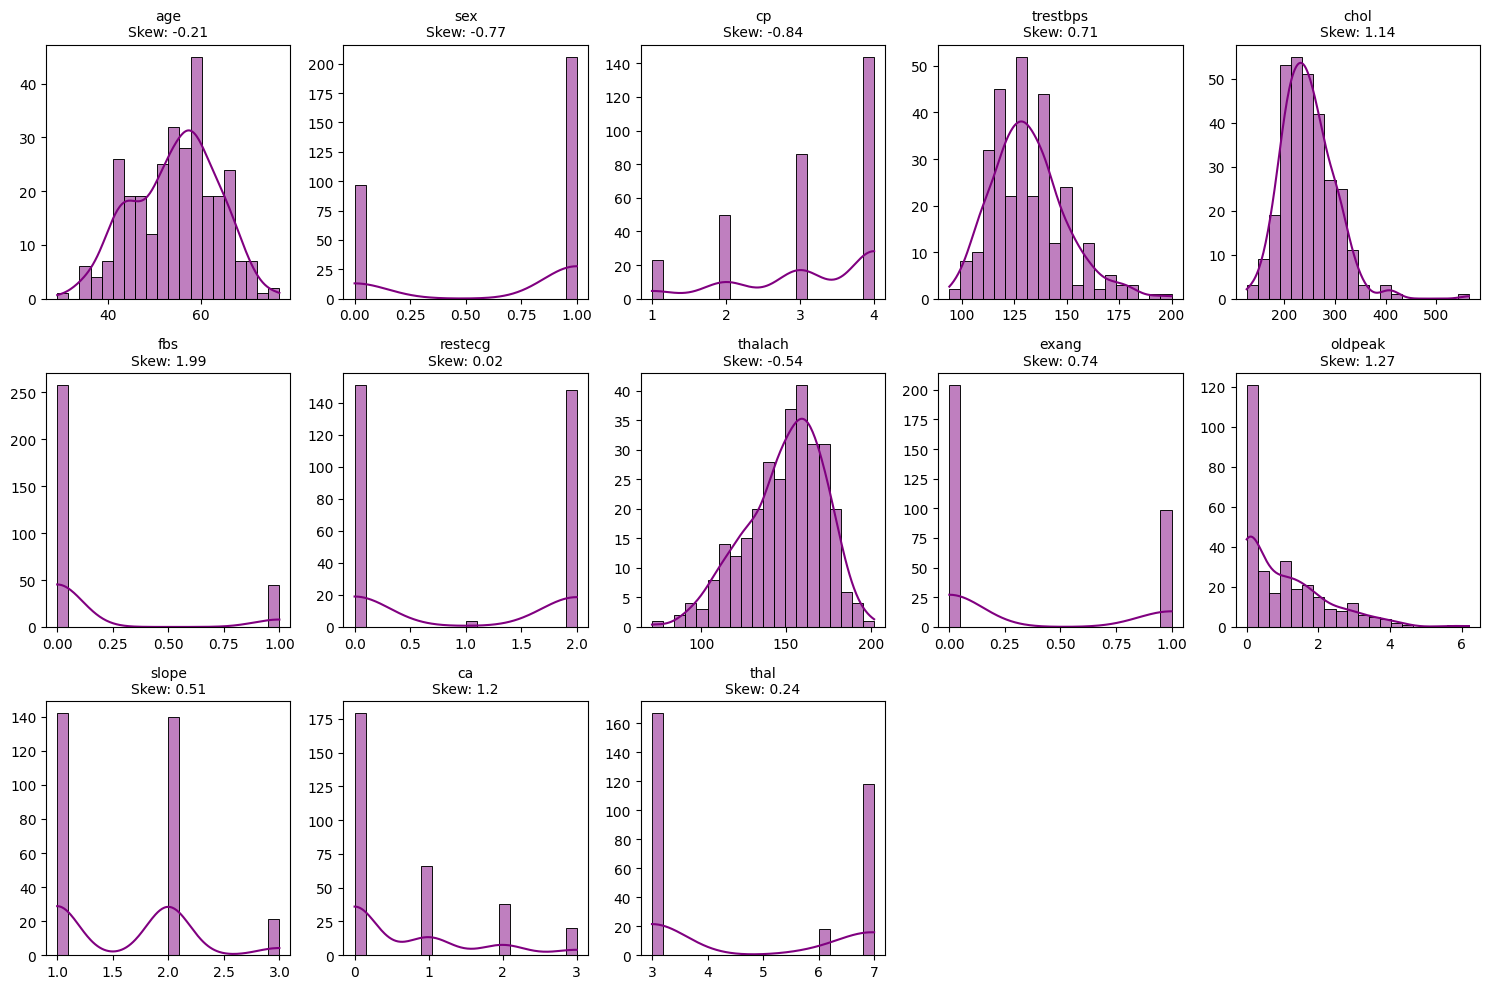


Ringkasan Kemiringan Data (Skewness):


,Kolom,Skewness,Status
0,age,-0.21,Normal
1,sex,-0.77,Moderately Skewed (Kiri)
2,cp,-0.84,Moderately Skewed (Kiri)
3,trestbps,0.71,Moderately Skewed (Kanan)
4,chol,1.14,Highly Skewed (Kanan)
5,fbs,1.99,Highly Skewed (Kanan)
6,restecg,0.02,Normal
7,thalach,-0.54,Moderately Skewed (Kiri)
8,exang,0.74,Moderately Skewed (Kanan)
9,oldpeak,1.27,Highly Skewed (Kanan)


In [27]:
# ==========================================
# 9. CEK DISTRIBUSI DATA (SKEWNESS)
# ==========================================
print("\n--- Analisis Kemiringan Distribusi Data (Skewness) ---")

# Ambil kolom numerik untuk dianalisis
numerical_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

# Siapkan list untuk menyimpan ringkasan nilai skewness
skewness_summary = []

# Setup canvas untuk visualisasi grid (Multiple Plots)
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    # Hitung nilai Skewness
    # Interpretasi:
    # 0 = Normal sempurna (Simetris)
    # Positif (> 0) = Miring ke Kanan (Ekor panjang ke kanan/nilai besar)
    # Negatif (< 0) = Miring ke Kiri (Ekor panjang ke kiri/nilai kecil)
    sk_value = dataset[col].skew()
    
    # Tentukan label status kemiringan berdasarkan threshold umum
    status = "Normal"
    if sk_value > 1: status = "Highly Skewed (Kanan)"
    elif sk_value < -1: status = "Highly Skewed (Kiri)"
    elif sk_value > 0.5: status = "Moderately Skewed (Kanan)"
    elif sk_value < -0.5: status = "Moderately Skewed (Kiri)"
    
    # Simpan ke dalam list summary
    skewness_summary.append({'Kolom': col, 'Skewness': round(sk_value, 2), 'Status': status})
    
    # Visualisasi Histogram & KDE
    plt.subplot(3, 5, i+1) # Membuat grid (3 baris x 5 kolom)
    sns.histplot(dataset[col], kde=True, color='purple', bins=20)
    plt.title(f'{col}\nSkew: {round(sk_value, 2)}', fontsize=10)
    plt.xlabel('') # Kosongkan label x biar tidak penuh
    plt.ylabel('') # Kosongkan label y

# Rapikan layout agar tidak bertumpuk
plt.tight_layout()
nama_file_skew = 'distribusi_skewness.png'
plt.savefig(os.path.join(save_dir, nama_file_skew), dpi=300, bbox_inches='tight')
print(f"📸 Gambar tersimpan: {nama_file_skew}")
plt.show()

# Tampilkan Tabel Ringkasan Skewness
print("\nRingkasan Kemiringan Data (Skewness):")
skew_df = pd.DataFrame(skewness_summary)
display(skew_df)

## Perubahan Nama Attribure

In [7]:
# ==========================================
# 10. RENAMING COLUMNS (FULL DESCRIPTIVE NAMES)
# ==========================================
print("--- MENGUBAH NAMA KOLOM DARI SINGKATAN KE NAMA LENGKAP ---")

# Kamus perubahan nama (Cleveland Dataset)
# Mapping dari Singkatan (Asli) -> Nama Lengkap (Standar Medis)
kamus_nama_lengkap = {
    'age': 'Age',
    'sex': 'Sex',
    'cp': 'Chest_Pain_Type',                # cp = Chest Pain
    'trestbps': 'Resting_Blood_Pressure',   # trestbps = Resting Blood Pressure
    'chol': 'Serum_Cholesterol',            # chol = Cholesterol
    'fbs': 'Fasting_Blood_Sugar',           # fbs = Fasting Blood Sugar
    'restecg': 'Resting_ECG',               # restecg = Resting Electrocardiographic
    'thalach': 'Max_Heart_Rate_Achieved',   # thalach = Max Heart Rate
    'exang': 'Exercise_Induced_Angina',     # exang = Exercise Angina
    'oldpeak': 'ST_Depression',             # oldpeak = ST Depression relative to rest
    'slope': 'ST_Slope',                    # slope = Slope of the peak exercise
    'ca': 'Number_of_Major_Vessels',        # ca = Number of vessels colored by flourosopy
    'thal': 'Thalassemia',                  # thal
    'label': 'Target_Diagnosis'             # label
}

# 1. Lakukan Rename
dataset.rename(columns=kamus_nama_lengkap, inplace=True)

# 2. Cek Hasilnya
print("\nNama kolom baru (Lengkap):")
print(dataset.columns.tolist())

# 3. Intip isinya sedikit untuk memastikan
print("\nContoh Data:")
print(dataset.head(3))

--- MENGUBAH NAMA KOLOM DARI SINGKATAN KE NAMA LENGKAP ---

Nama kolom baru (Lengkap):
['Age', 'Sex', 'Chest_Pain_Type', 'Resting_Blood_Pressure', 'Serum_Cholesterol', 'Fasting_Blood_Sugar', 'Resting_ECG', 'Max_Heart_Rate_Achieved', 'Exercise_Induced_Angina', 'ST_Depression', 'ST_Slope', 'Number_of_Major_Vessels', 'Thalassemia', 'Target_Diagnosis']

Contoh Data:
   Age  Sex  Chest_Pain_Type  Resting_Blood_Pressure  Serum_Cholesterol  \
0   63    1                1                     145                233   
1   37    1                3                     130                250   
2   41    0                2                     130                204   

   Fasting_Blood_Sugar  Resting_ECG  Max_Heart_Rate_Achieved  \
0                    1            2                      150   
1                    0            0                      187   
2                    0            2                      172   

   Exercise_Induced_Angina  ST_Depression  ST_Slope  Number_of_Major_Vessels 

## Simpan File 

In [9]:
# ==========================================
# 11. SAVING (FINALISASI)
# ==========================================

output_clean_path = '../data/cleveland_clean.csv'
dataset.to_csv(output_clean_path, index=False)

print(f"\nData bersih dengan nama baru berhasil disimpan ke: {output_clean_path}")


Data bersih dengan nama baru berhasil disimpan ke: ../data/cleveland_clean.csv
